# 05.5 - Decision Trees

**Phase:** 05 - Machine Learning

**Status:** VERIFIED

---

## 1. What Are We Solving?

Decision trees make predictions by recursively splitting data on feature thresholds. We implement a simplified tree from scratch, then use scikit-learn's version.

## 2. Why Does This Matter?

Decision trees are interpretable, handle mixed data, and are the building blocks of random forests and gradient boosting (the best tabular models).

## 3. Prerequisites

- Phase 02 (Math), Phase 03 (Statistics)

## 4. Learning Objectives

By the end of this unit, you should be able to:
- Explain how trees split data
- Compute entropy, Gini impurity, and information gain
- Build a simplified tree from scratch
- Use sklearn's DecisionTreeClassifier

## 5. Mental Model

A tree recursively splits data to reduce impurity:

1. At each node, find the feature + threshold that best separates classes.
2. 'Best' = maximizes information gain (reduces impurity).
3. Recurse on each child until pure or max depth.

Impurity measures: entropy = -sum(p*log(p)), Gini = 1 - sum(p^2).


## 6. Impurity Measures

Compute entropy and Gini for different class distributions.


In [1]:
import numpy as np

def entropy(p):
    p = np.clip(p, 1e-15, 1)
    return -np.sum(p * np.log(p))

def gini(p):
    return 1 - np.sum(p ** 2)

for p1 in [0.0, 0.25, 0.5, 0.75, 1.0]:
    p = np.array([p1, 1 - p1])
    print(f"p=[{p1:.2f}, {1-p1:.2f}]: entropy={entropy(p):.3f}, gini={gini(p):.3f}")
print("\nImpurity is 0 when pure, max when 50/50.")


p=[0.00, 1.00]: entropy=0.000, gini=0.000
p=[0.25, 0.75]: entropy=0.562, gini=0.375
p=[0.50, 0.50]: entropy=0.693, gini=0.500
p=[0.75, 0.25]: entropy=0.562, gini=0.375
p=[1.00, 0.00]: entropy=0.000, gini=0.000

Impurity is 0 when pure, max when 50/50.


## 7. Generate Data

Create a simple 2D classification dataset.


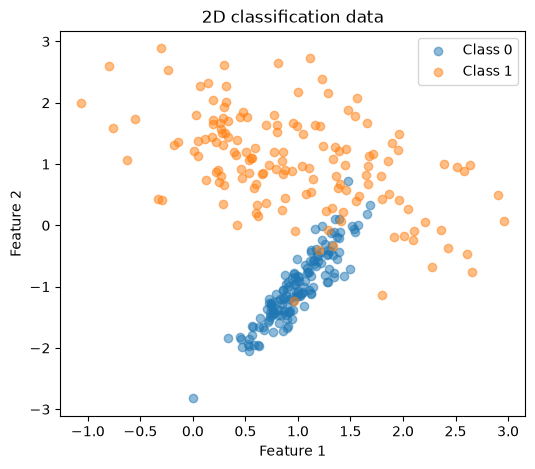

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

np.random.seed(42)
X, y = make_classification(n_samples=300, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], alpha=0.5, label="Class 0")
plt.scatter(X[y==1, 0], X[y==1, 1], alpha=0.5, label="Class 1")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("2D classification data")
plt.legend()
plt.show()


## 8. Simplified Tree from Scratch

Implement a simple decision tree that finds the best split by maximizing information gain.


In [3]:
class SimpleTree:
    def __init__(self, max_depth=3):
        self.max_depth = max_depth
        self.tree = None

    def _gini(self, y):
        if len(y) == 0:
            return 0
        p = np.bincount(y) / len(y)
        return 1 - np.sum(p ** 2)

    def _best_split(self, X, y):
        best_gain = -1
        best = None
        parent_gini = self._gini(y)
        n = len(y)
        for f in range(X.shape[1]):
            thresholds = np.unique(X[:, f])
            for t in thresholds:
                left = y[X[:, f] <= t]
                right = y[X[:, f] > t]
                if len(left) == 0 or len(right) == 0:
                    continue
                gain = parent_gini - (len(left)/n * self._gini(left) + len(right)/n * self._gini(right))
                if gain > best_gain:
                    best_gain = gain
                    best = (f, t)
        return best

    def _build(self, X, y, depth):
        if depth >= self.max_depth or len(np.unique(y)) == 1:
            return np.bincount(y).argmax()
        split = self._best_split(X, y)
        if split is None:
            return np.bincount(y).argmax()
        f, t = split
        left_mask = X[:, f] <= t
        return {
            "feature": f, "threshold": t,
            "left": self._build(X[left_mask], y[left_mask], depth + 1),
            "right": self._build(X[~left_mask], y[~left_mask], depth + 1),
        }

    def fit(self, X, y):
        self.tree = self._build(X, y, 0)
        return self

    def _predict_one(self, x, node):
        if not isinstance(node, dict):
            return node
        if x[node["feature"]] <= node["threshold"]:
            return self._predict_one(x, node["left"])
        return self._predict_one(x, node["right"])

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

tree = SimpleTree(max_depth=3).fit(X_train, y_train)
acc = accuracy_score(y_test, tree.predict(X_test))
print(f"Simple tree test accuracy: {acc:.3f}")


Simple tree test accuracy: 0.944


## 9. Compare to scikit-learn

Use sklearn's DecisionTreeClassifier.


In [4]:
sk_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
sk_tree.fit(X_train, y_train)
sk_acc = accuracy_score(y_test, sk_tree.predict(X_test))
print(f"sklearn tree test accuracy: {sk_acc:.3f}")
print(f"Simple tree test accuracy:  {acc:.3f}")
print("\nBoth capture the same structure.")


sklearn tree test accuracy: 0.911
Simple tree test accuracy:  0.944

Both capture the same structure.


## 10. Visualize the Tree

Decision trees are interpretable - we can see the splits.


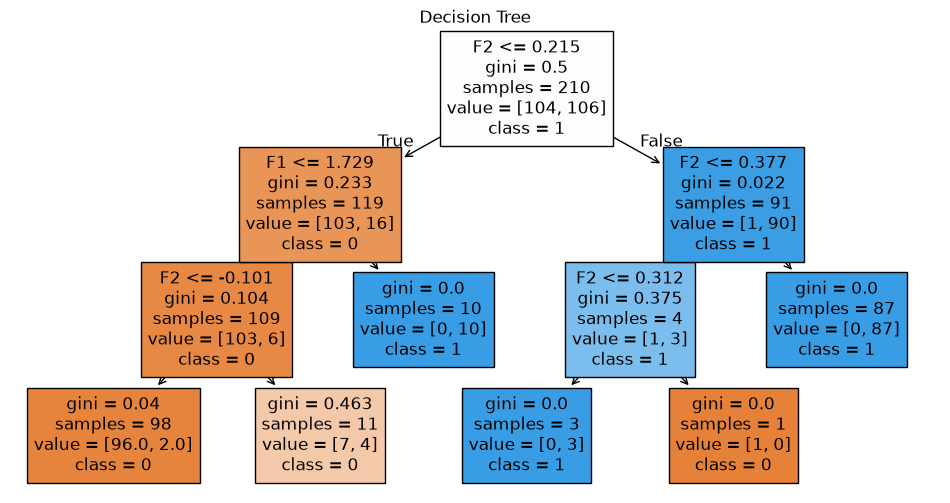

In [5]:
plt.figure(figsize=(12, 6))
plot_tree(sk_tree, filled=True, feature_names=["F1", "F2"], class_names=["0", "1"])
plt.title("Decision Tree")
plt.show()


## 11. Overfitting: Depth vs Performance

Deep trees overfit. Let's see the effect of max_depth.


In [6]:
for depth in [1, 3, 5, 10, 20]:
    t = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train, y_train)
    tr = accuracy_score(y_train, t.predict(X_train))
    te = accuracy_score(y_test, t.predict(X_test))
    print(f"depth={depth:2d}: train={tr:.3f}, test={te:.3f}")
print("\nDeep trees fit training data perfectly but generalize worse.")


depth= 1: train=0.919, test=0.922
depth= 3: train=0.971, test=0.911
depth= 5: train=0.990, test=0.911
depth=10: train=1.000, test=0.911


depth=20: train=1.000, test=0.911

Deep trees fit training data perfectly but generalize worse.


## 12. Failure Case: Unconstrained Tree

Without constraints, trees overfit badly.


In [7]:
t_full = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print(f"Unconstrained: train={accuracy_score(y_train, t_full.predict(X_train)):.3f}, "
      f"test={accuracy_score(y_test, t_full.predict(X_test)):.3f}")
print("\nPerfect training accuracy but worse test - overfitting.")


Unconstrained: train=1.000, test=0.911

Perfect training accuracy but worse test - overfitting.


## 13. Debugging: Common Errors

- **Overfitting**: too deep, no constraints.
- **Unstable**: small data changes cause big tree changes.
- **Bias**: trees favor features with many values.

## 14. Real-World Considerations

- Limit depth, min_samples_split, min_samples_leaf.
- Use pruning.
- Trees are the base of random forests and boosting.

## 15. Common Mistakes

- Not constraining depth.
- Expecting stability from a single tree.

## 16. When NOT to Use

- When you need smooth decision boundaries.
- When a single tree is too unstable.

## 17. Challenge

Compute the information gain of a specific split manually.


In [8]:
# Challenge: manual information gain
# Split on feature 0 at threshold 0
f0 = X_train[:, 0]
left = y_train[f0 <= 0]
right = y_train[f0 > 0]
parent = y_train

def gini_calc(y):
    if len(y) == 0: return 0
    p = np.bincount(y) / len(y)
    return 1 - np.sum(p ** 2)

gain = gini_calc(parent) - (len(left)/len(parent) * gini_calc(left) + len(right)/len(parent) * gini_calc(right))
print(f"Parent Gini: {gini_calc(parent):.3f}")
print(f"Left Gini:   {gini_calc(left):.3f} (n={len(left)})")
print(f"Right Gini:  {gini_calc(right):.3f} (n={len(right)})")
print(f"Information gain: {gain:.3f}")
print("\nHigher gain = better split.")


Parent Gini: 0.500
Left Gini:   0.165 (n=11)
Right Gini:  0.499 (n=199)
Information gain: 0.018

Higher gain = better split.


## 18. Closed-Book Recall

Without looking back:

1. What is entropy? Gini impurity?
2. How does a tree choose a split?
3. Why do deep trees overfit?

## 19. Teach-Back Questions

Explain to another person:

- How a decision tree makes predictions.
- The overfitting problem with deep trees.

## 20. Summary

You implemented a decision tree from scratch, used sklearn's version, and explored overfitting. Trees are the foundation of random forests and boosting.

## 21. Further Experiment

- Try entropy vs Gini criterion.
- Add min_samples_leaf.

## 22. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, matplotlib, scikit-learn
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
